In [ ]:
import  pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [5]:
dataset = pd.read_csv('Training.csv')
dataset

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo
4916,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,Acne
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Urinary tract infection
4918,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,0,0,0,Psoriasis


In [6]:
X = dataset.drop('prognosis', axis=1)
X += np.random.normal(0, 0.1, X.shape)
y = dataset['prognosis']

# ecoding prognonsis
le = LabelEncoder()
le.fit(y)
Y = le.transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
y_train_noisy = y_train.copy()

num_noisy = int(0.20 * len(y_train_noisy))
noise_indices = np.random.choice(len(y_train_noisy), size=num_noisy, replace=False)
for idx in noise_indices:
    current_label = y_train_noisy[idx]
    possible_labels = np.setdiff1d(np.unique(y_train_noisy), current_label)
    y_train_noisy[idx] = np.random.choice(possible_labels)

Training Models and Evaluating...

Training SVC...
Model: SVC
Accuracy: 0.9939


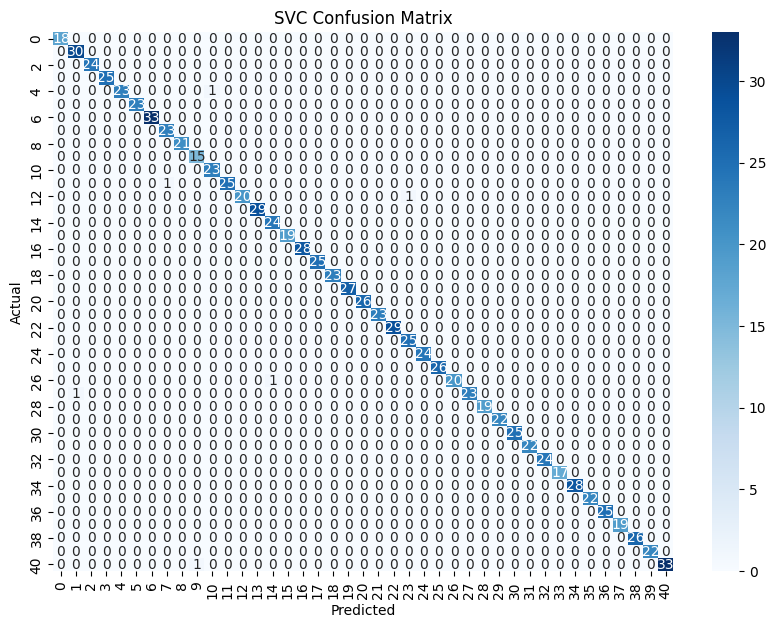

Training RandomForest...
Model: RandomForest
Accuracy: 1.0000


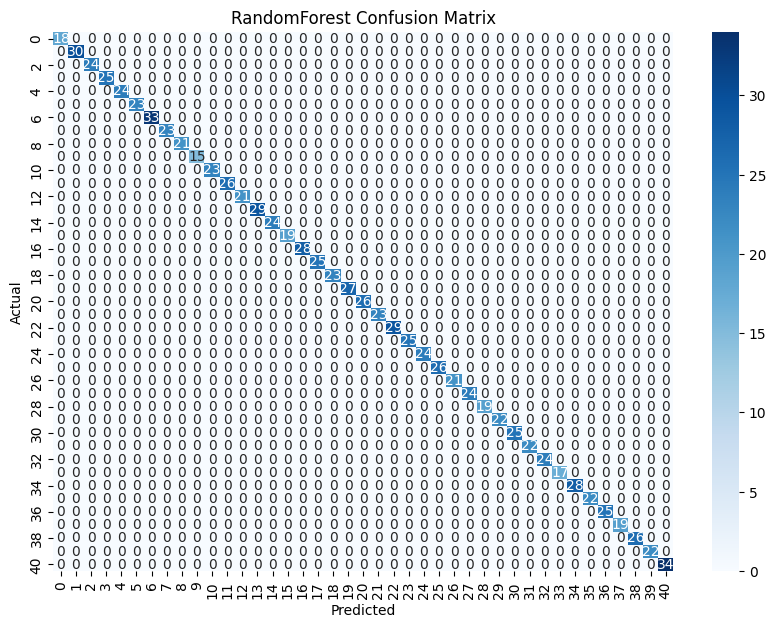

Training KNeighbors...
Model: KNeighbors
Accuracy: 0.9929


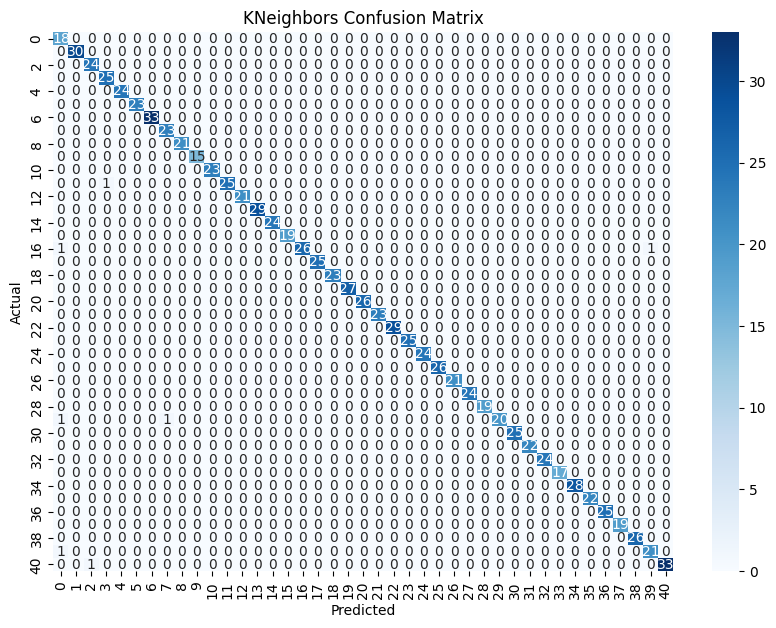

Training DecisionTree...
Model: DecisionTree
Accuracy: 0.1596


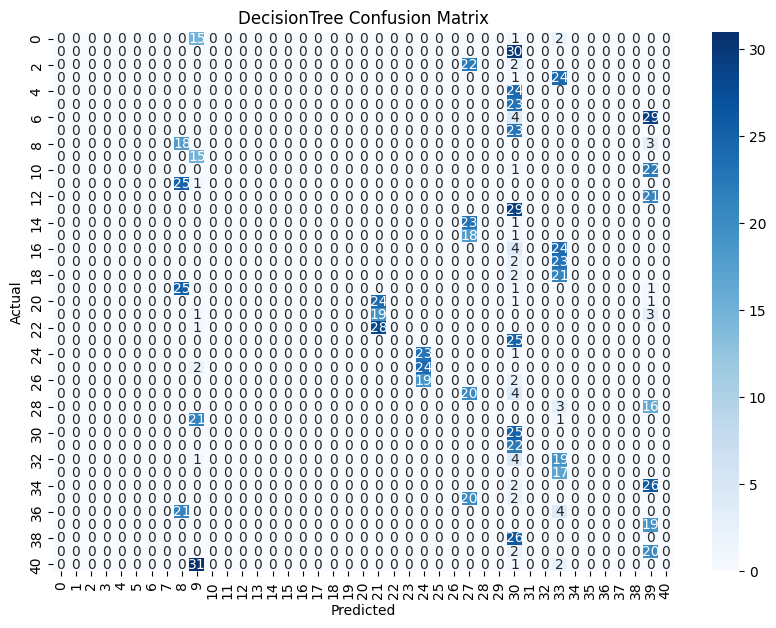

In [5]:
models = {
    'SVC': SVC(kernel='linear'),
    'RandomForest': RandomForestClassifier(n_estimators=101, random_state=42),
    'KNeighbors': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(criterion = 'entropy',max_depth = 3, random_state = 42)
}

print("Training Models and Evaluating...\n")

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train_noisy)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


Original feature shape: (4920, 132)
Reduced feature shape after PCA: (4920, 90)
Training on PCA reduced features...

Training SVC...
Model: SVC
Accuracy: 1.0000


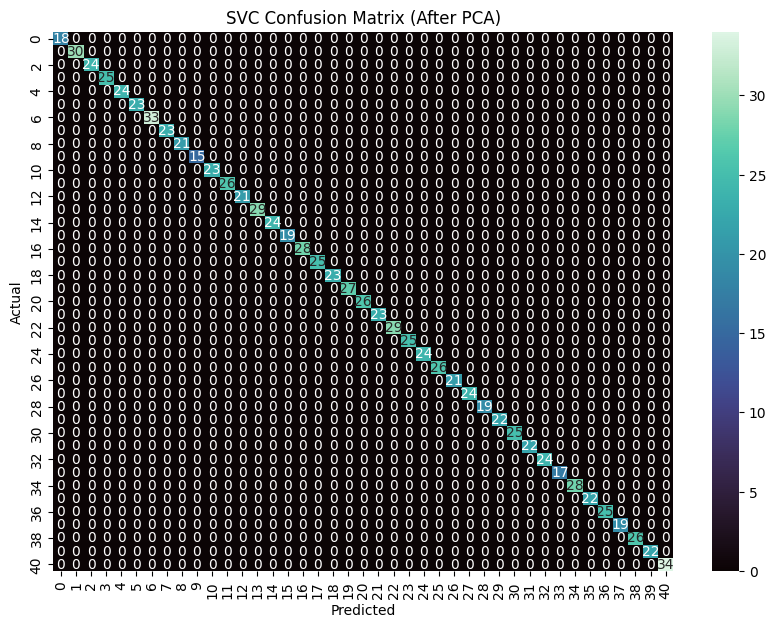

Training RandomForest...
Model: RandomForest
Accuracy: 0.9980


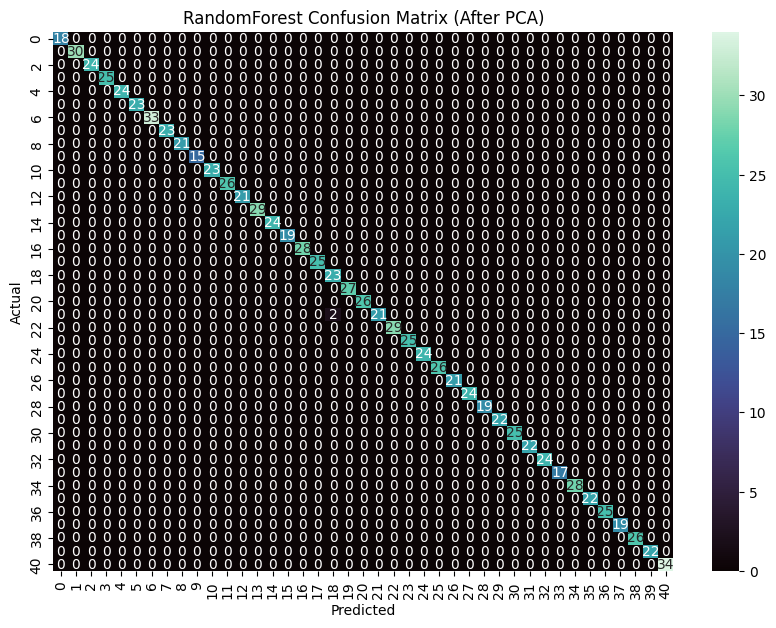

Training KNeighbors...
Model: KNeighbors
Accuracy: 1.0000


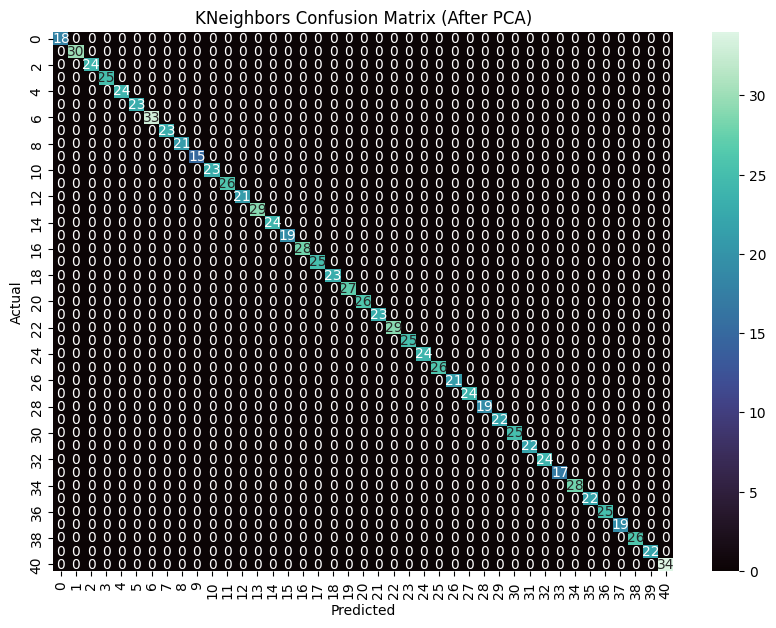

Training DecisionTree...
Model: DecisionTree
Accuracy: 0.9756


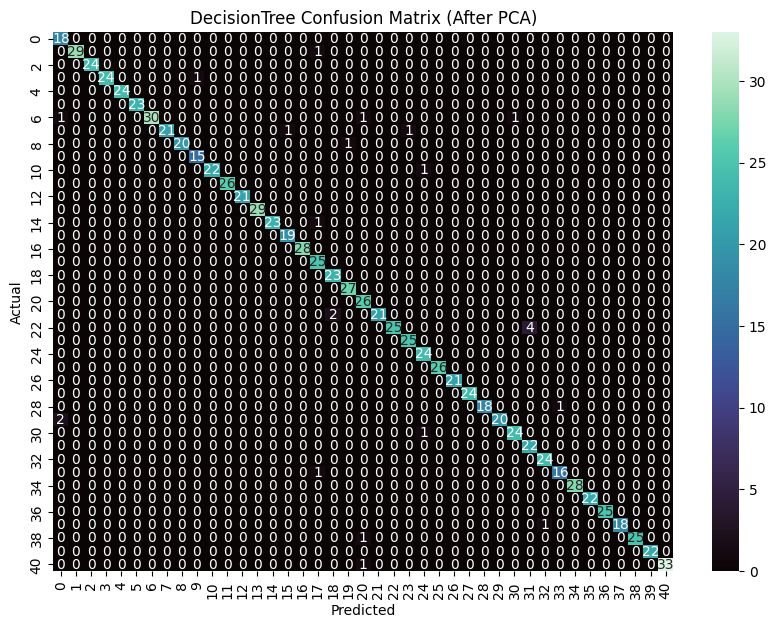

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=90)
X_pca = pca.fit_transform(X_scaled)

print(f"Original feature shape: {X.shape}")
print(f"Reduced feature shape after PCA: {X_pca.shape}")

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, Y, test_size=0.2, random_state=42)

models = {
    'SVC': SVC(kernel='linear'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNeighbors': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}
print("Training on PCA reduced features...\n")

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train_pca, y_train_pca)

    predictions = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test_pca, predictions)
    cm = confusion_matrix(y_test_pca, predictions)

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako')
    plt.title(f'{model_name} Confusion Matrix (After PCA)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [7]:
# selecting svc
svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
ypred = svc.predict(X_test)
accuracy_score(y_test,ypred)

1.0

In [8]:
# save svc
import pickle
pickle.dump(svc,open('model.pkl','wb'))

In [9]:
# load model
svc = pickle.load(open('model.pkl','rb'))

In [14]:
# test 1:
print("predicted disease :",svc.predict(X_test.iloc[10].values.reshape(1,-1)))
print("Actual Disease :", y_test[10])

predicted disease : [38]
Actual Disease : 38


/home/Harsh/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [11]:
# test 2:
print("predicted disease :",svc.predict(X_test.iloc[100].values.reshape(1,-1)))
print("Actual Disease :", y_test[100])

predicted disease : [23]
Actual Disease : 23


/home/Harsh/.local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
